# QLoRA Direct Preference Optimization (DPO) for Qwen/Qwen2.5-7B-Instruct

This notebook trains using the DPO objective, optimizing the margin between the chosen and rejected responses.

In [1]:
# If you are in Colab/Kaggle, run this once.
# Restart the runtime after installation if the environment asks for it.

%pip install -q -U \
    "transformers>=4.38.0" \
    "accelerate>=0.30.0" \
    "datasets>=2.18.0" \
    "peft>=0.10.0" \
    "trl>=0.8.6" \
    "bitsandbytes>=0.43.0" \
    "pandas>=2.0.0" \
    "scikit-learn>=1.4.0" \
    "matplotlib>=3.8.0"

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import gc
import math
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from datasets import Dataset
from sklearn.model_selection import train_test_split

from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    BitsAndBytesConfig,
    set_seed,
)

from peft import (
    LoraConfig,
    get_peft_model,
    prepare_model_for_kbit_training,
)

from trl import DPOTrainer, DPOConfig

In [ ]:
MODEL_NAME = "Qwen/Qwen2.5-7B-Instruct"
DATA_PATH = "final_pairs_dpo_Qwen2.5-7B-Instruct.csv" # Update to generated DPO dataset
OUTPUT_DIR = "./qwen25_7b_dpo_qlora"
SEED = 42

# DPO / Training config
MAX_LENGTH = 1536
NUM_EPOCHS = 1
LEARNING_RATE = 5e-6
TRAIN_BATCH_SIZE = 8
EVAL_BATCH_SIZE = 8
GRADIENT_ACCUMULATION_STEPS = 8

# DPO Specific Config
BETA = 0.5

# LoRA config
LORA_R = 16
LORA_ALPHA = 32
LORA_DROPOUT = 0.05

set_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if not torch.cuda.is_available():
    raise RuntimeError("This notebook expects a CUDA GPU runtime.")

DEVICE_NAME = torch.cuda.get_device_name(0)
BF16_SUPPORTED = torch.cuda.is_bf16_supported()
COMPUTE_DTYPE = torch.bfloat16 if BF16_SUPPORTED else torch.float16

torch.backends.cuda.matmul.allow_tf32 = True

print(f"GPU: {DEVICE_NAME}")
print(f"BF16 supported: {BF16_SUPPORTED}")
print(f"Compute dtype: {COMPUTE_DTYPE}")

GPU: NVIDIA GeForce RTX 3090
BF16 supported: True
Compute dtype: torch.bfloat16


In [ ]:
df = pd.read_csv(DATA_PATH)

df = df.rename(columns={
    "question": "prompt", 
    "answer_w": "chosen", 
    "answer_l": "rejected"
})

df["prompt"] = df["prompt"].astype(str).str.strip()
df["chosen"] = df["chosen"].astype(str).str.strip()
df["rejected"] = df["rejected"].astype(str).str.strip()

df = df[(df["prompt"] != "") & (df["chosen"] != "") & (df["rejected"] != "")]
df = df.drop_duplicates().reset_index(drop=True)

print(f"Total DPO triplets: {len(df):,}")
display(df.head(3))

train_df, val_df = train_test_split(
    df,
    test_size=0.20,
    random_state=SEED,
    shuffle=True,
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

print(f"Train size: {len(train_df):,}")
print(f"Val size:   {len(val_df):,}")

train_ds = Dataset.from_pandas(train_df, preserve_index=False)
val_ds = Dataset.from_pandas(val_df, preserve_index=False)

Total DPO triplets: 4,437


,prompt,chosen,rejected
0,How is the operational effectiveness of the Ru...,The Russian Black Sea Fleet is portrayed as la...,The operational effectiveness of the Russian B...
1,What does Russia's attempt to develop naval dr...,Russia's efforts to copy Ukrainian naval drone...,Russia's development of naval drones highlight...
2,"Why is the Black Sea described as a ""gray zone...","The Black Sea is considered a ""gray zone"" beca...","The Black Sea is described as a ""gray zone"" fo..."


Train size: 3,549
Val size:   888


In [ ]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

tokenizer.padding_side = "left"

print("pad_token:", tokenizer.pad_token)
print("eos_token:", tokenizer.eos_token)

SYSTEM_PROMPT = (
    "You are an objective analytical system. Answer the question directly in a "
    "single, concise paragraph of one to two sentences. Write exclusively in plain text. "
    "You are strictly forbidden from using bullet points, numbered lists, markdown formatting, "
    "or introductory filler phrases. Provide a direct, declarative explanation."
)

def format_dpo_dataset(example):
    """
    Applies the chat template to the prompt.
    Leaves chosen/rejected as raw strings but appends the EOS token so the model learns to stop.
    """
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": example["prompt"]}
    ]
    
    formatted_prompt = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )
    
    return {
        "prompt": formatted_prompt,
        "chosen": example["chosen"] + tokenizer.eos_token,
        "rejected": example["rejected"] + tokenizer.eos_token,
    }

train_ds = train_ds.map(format_dpo_dataset, remove_columns=train_ds.column_names)
val_ds = val_ds.map(format_dpo_dataset, remove_columns=val_ds.column_names)

print("\n=== Formatted Prompt Example ===")
print(train_ds[0]["prompt"])
print("\n=== Chosen ===")
print(train_ds[0]["chosen"])
print("\n=== Rejected ===")
print(train_ds[0]["rejected"])

pad_token: <|endoftext|>
eos_token: <|im_end|>


Map:   0%|          | 0/3549 [00:00<?, ? examples/s]

Map:   0%|          | 0/888 [00:00<?, ? examples/s]


=== Formatted Prompt Example ===
<|im_start|>system
You are an objective analytical system. Answer the question directly in a single, concise paragraph of one to two sentences. Write exclusively in plain text. You are strictly forbidden from using bullet points, numbered lists, markdown formatting, or introductory filler phrases. Provide a direct, declarative explanation.<|im_end|>
<|im_start|>user
Why is the strategic weakening of the aggressor considered essential for ending the conflict?<|im_end|>
<|im_start|>assistant


=== Chosen ===
Weakening the aggressor through battlefield losses, economic damage, and sustained international support is the key to ending the war because it forces the aggressor to face an unpredictable future and prevents them from negotiating from a position of strength.<|im_end|>

=== Rejected ===
Strategically weakening the aggressor is essential for ending conflicts as it diminishes their capacity to continue aggression, thereby creating conditions for nego

In [6]:
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=COMPUTE_DTYPE,
)

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=bnb_config,
    torch_dtype=COMPUTE_DTYPE,
    device_map={"": 0},
)

model.config.use_cache = False
model = prepare_model_for_kbit_training(model)

peft_config = LoraConfig(
    r=LORA_R,
    lora_alpha=LORA_ALPHA,
    lora_dropout=LORA_DROPOUT,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules=[
        "q_proj", "k_proj", "v_proj", "o_proj",
        "gate_proj", "up_proj", "down_proj",
    ],
)

model = get_peft_model(model, peft_config)
model.print_trainable_parameters()

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

/venv/main/lib/python3.12/site-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


trainable params: 40,370,176 || all params: 7,655,986,688 || trainable%: 0.5273


In [7]:
dpo_config = DPOConfig(
    output_dir=OUTPUT_DIR,
    beta=BETA,
    max_length=MAX_LENGTH,
    
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=TRAIN_BATCH_SIZE,
    per_device_eval_batch_size=EVAL_BATCH_SIZE,
    gradient_accumulation_steps=GRADIENT_ACCUMULATION_STEPS,

    learning_rate=LEARNING_RATE,
    lr_scheduler_type="cosine",
    warmup_ratio=0.1,
    weight_decay=0.05,
    
    logging_steps=1,
    eval_strategy="steps",
    eval_steps=50,
    save_strategy="steps",
    save_steps=50,
    save_total_limit=2,

    bf16=BF16_SUPPORTED,
    fp16=not BF16_SUPPORTED,
    optim="paged_adamw_8bit",
    gradient_checkpointing=True,

    report_to="none",
    remove_unused_columns=False,
)

trainer = DPOTrainer(
    model=model,
    args=dpo_config,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    processing_class=tokenizer,
)

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Adding EOS to train dataset:   0%|          | 0/3549 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/3549 [00:00<?, ? examples/s]

Adding EOS to eval dataset:   0%|          | 0/888 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/888 [00:00<?, ? examples/s]

In [8]:
print("\n=== Starting DPO Training ===")
train_result = trainer.train()

print("\n=== Final train result ===")
print(train_result)

eval_metrics = trainer.evaluate()
print("\n=== Eval metrics ===")
for k, v in eval_metrics.items():
    print(f"{k}: {v}")
    
trainer.save_model(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)

print(f"Saved DPO adapter checkpoint to: {OUTPUT_DIR}")

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.



=== Starting DPO Training ===


Step,Training Loss,Validation Loss
50,0.000148,0.000121
56,0.000639,0.000117



=== Final train result ===
TrainOutput(global_step=56, training_loss=0.06892514423306498, metrics={'train_runtime': 1707.5135, 'train_samples_per_second': 2.078, 'train_steps_per_second': 0.033, 'total_flos': 4.284061948899533e+16, 'train_loss': 0.06892514423306498})


Training Loss,Validation Loss,Step
0.000639,0.000117,56



=== Eval metrics ===
eval_loss: 0.00011698106391122565
Saved DPO adapter checkpoint to: ./qwen25_7b_dpo_qlora


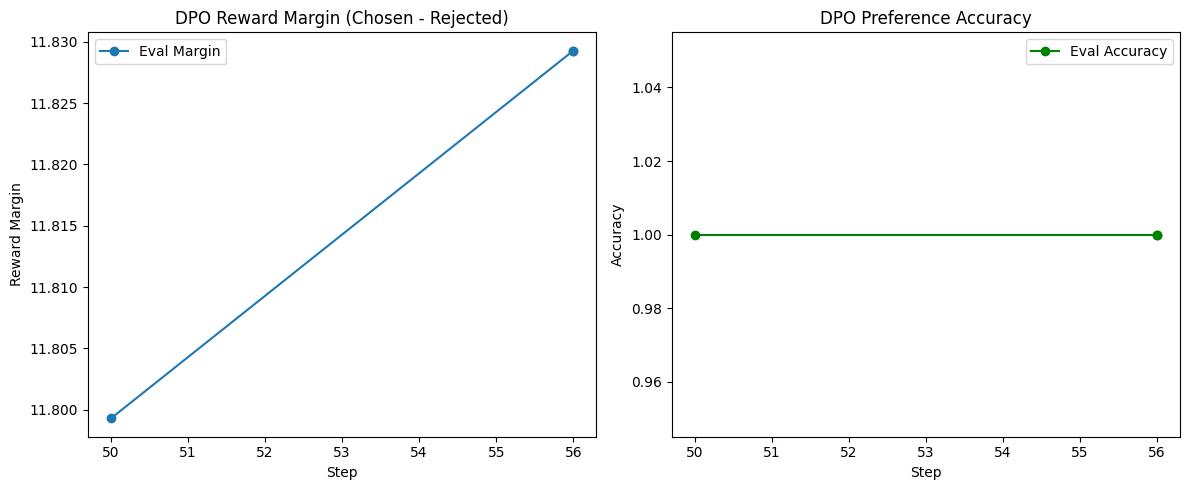

In [ ]:
logs_df = pd.DataFrame(trainer.state.log_history)

if "eval_rewards/margins" in logs_df.columns:
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    eval_logs = logs_df.dropna(subset=["eval_rewards/margins"])
    plt.plot(eval_logs["step"], eval_logs["eval_rewards/margins"], marker='o', label="Eval Margin")
    plt.xlabel("Step")
    plt.ylabel("Reward Margin")
    plt.title("DPO Reward Margin (Chosen - Rejected)")
    plt.legend()
    
    plt.subplot(1, 2, 2)
    eval_logs_acc = logs_df.dropna(subset=["eval_rewards/accuracies"])
    plt.plot(eval_logs_acc["step"], eval_logs_acc["eval_rewards/accuracies"], marker='o', color='green', label="Eval Accuracy")
    plt.xlabel("Step")
    plt.ylabel("Accuracy")
    plt.title("DPO Preference Accuracy")
    plt.legend()
    
    plt.tight_layout()
    plt.show()

In [16]:
model.eval()

@torch.no_grad()
def generate_aligned_answer(
    question: str,
    max_new_tokens: int = 180,
    temperature: float = 0.1,
    top_p: float = 0.9,
    do_sample: bool = True,
):
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": question},
    ]
    prompt = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )

    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

    generate_kwargs = {
        "max_new_tokens": max_new_tokens,
        "do_sample": do_sample,
        "pad_token_id": tokenizer.pad_token_id,
        "eos_token_id": tokenizer.eos_token_id,
    }
    if do_sample:
        generate_kwargs.update({"temperature": temperature, "top_p": top_p})

    generated = model.generate(**inputs, **generate_kwargs)

    new_tokens = generated[0][inputs["input_ids"].shape[1]:]
    return tokenizer.decode(new_tokens, skip_special_tokens=True).strip()

def preview_answer(question: str, **generation_kwargs):
    answer = generate_aligned_answer(question, **generation_kwargs)
    print("=== Question ===")
    print(question)
    print("\n=== Aligned Model Answer ===")
    print(answer)
    return answer

In [22]:
CUSTOM_PROMPT = """
What do you think about current state of Russia in the Russian-Ukrainian war?
""".strip()

aligned_answer = preview_answer(
    CUSTOM_PROMPT,
    max_new_tokens=180,
    temperature=0.1,
    top_p=0.9,
)

=== Question ===
What do you think about current state of Russia in the Russian-Ukrainian war?

=== Aligned Model Answer ===
Russia maintains significant military presence and influence in eastern Ukraine despite international condemnation and sanctions, while Ukraine continues to resist Russian-backed separatists.
